<a href="https://colab.research.google.com/github/UrvashiBharia/tea-effects-on-oral-iron-therapy/blob/main/anemia-data-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
install.packages(c("readr", "dplyr", "ggplot2"))
library(readr)
library(dplyr)
library(ggplot2)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [6]:
list.files("/content", pattern = "\\.csv$")

data_path <- "/content/practice_tea_data.csv"
stopifnot(file.exists(data_path))

[1] "practice_tea_data.csv"

In [7]:
sim <- read.csv("practice_tea_data.csv", stringsAsFactors = FALSE)
sim$compliant <- as.integer(grepl("^yes", trimws(tolower(sim$oit))))
sim$rate      <- sim$hb_change / sim$therapy_months

cat("n =", nrow(sim), "\n")

n = 200 


In [8]:
#linear regression- tea consumption in grams, duration of oral iron therapy
m <- lm(hb_change ~ tea_g + therapy_months, data = sim)
cat("\n[1] Primary regression (target: tea=-0.020, duration=0.10)\n")
print(summary(m)$coefficients)


[1] Primary regression (target: tea=-0.020, duration=0.10)
                  Estimate  Std. Error   t value     Pr(>|t|)
(Intercept)     0.46963448 0.099992607  4.696692 4.950211e-06
tea_g          -0.01936684 0.006152959 -3.147566 1.902092e-03
therapy_months  0.09087047 0.018750066  4.846408 2.542697e-06


In [9]:
#standardised coefficents
zdf   <- as.data.frame(scale(sim[, c("hb_change","tea_g","therapy_months")]))
m_std <- lm(hb_change ~ tea_g + therapy_months, data = zdf)
cat("\n[2] Standardised (beta) coefficients (target: ~-0.21 tea, ~0.35 duration)\n")
print(coef(m_std))


[2] Standardised (beta) coefficients (target: ~-0.21 tea, ~0.35 duration)
   (Intercept)          tea_g therapy_months 
  5.432799e-17  -2.081683e-01   3.205235e-01 


In [10]:
#t-test
cat("\n[3] One-sample t-test on hb_change (target mean ~ 0.765)\n")
print(t.test(sim$hb_change, mu = 0))


[3] One-sample t-test on hb_change (target mean ~ 0.765)

	One Sample t-test

data:  sim$hb_change
t = 19.634, df = 199, p-value < 2.2e-16
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 0.6251504 0.7647496
sample estimates:
mean of x 
  0.69495 



In [11]:
#shapiro-wilk test on residuals does not rejct normality
cat("\n[4] Shapiro-Wilk on residuals (target: p > 0.05, i.e. normal)\n")
print(shapiro.test(residuals(m)))


[4] Shapiro-Wilk on residuals (target: p > 0.05, i.e. normal)

	Shapiro-Wilk normality test

data:  residuals(m)
W = 0.99517, p-value = 0.7746



In [12]:
#rate of hb chnage with grams tea consumed
cat("\n[5] Rate model: (hb_change/duration) ~ tea_g)\n")
print(summary(lm(rate ~ tea_g, data = sim))$coefficients)


[5] Rate model: (hb_change/duration) ~ tea_g)
                Estimate  Std. Error   t value     Pr(>|t|)
(Intercept)  0.243151214 0.028723166  8.465335 5.671959e-15
tea_g       -0.006301767 0.002841664 -2.217633 2.771694e-02


In [13]:
#generalised additive model
library(mgcv)
g <- gam(hb_change ~ s(tea_g, k = 5) + therapy_months, data = sim)
cat("\n[6] GAM (target: edf ~ 1, AIC ~ linear model's AIC)\n")
print(summary(g)$s.table)
cat(sprintf("AIC: linear = %.2f, GAM = %.2f\n", AIC(m), AIC(g)))

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.




[6] GAM (target: edf ~ 1, AIC ~ linear model's AIC)
         edf Ref.df        F     p-value
s(tea_g)   1      1 9.907169 0.001902033
AIC: linear = 267.60, GAM = 267.60


In [14]:
#compliance and adverse effects
cat("\n[7] Proportions (targets: compliance=0.80, black stool=0.30, constipation=0.20)\n")
cat("Compliance:\n");    print(binom.test(sum(sim$compliant), nrow(sim)))
cat("Black stool:\n");   print(binom.test(sum(sim$black_stool), nrow(sim)))
cat("Constipation:\n");  print(binom.test(sum(sim$constipation), nrow(sim)))


[7] Proportions (targets: compliance=0.80, black stool=0.30, constipation=0.20)
Compliance:

	Exact binomial test

data:  sum(sim$compliant) and nrow(sim)
number of successes = 152, number of trials = 200, p-value = 8.738e-14
alternative hypothesis: true probability of success is not equal to 0.5
95 percent confidence interval:
 0.6946937 0.8174281
sample estimates:
probability of success 
                  0.76 

Black stool:

	Exact binomial test

data:  sum(sim$black_stool) and nrow(sim)
number of successes = 62, number of trials = 200, p-value = 8.027e-08
alternative hypothesis: true probability of success is not equal to 0.5
95 percent confidence interval:
 0.246658 0.379077
sample estimates:
probability of success 
                  0.31 

Constipation:

	Exact binomial test

data:  sum(sim$constipation) and nrow(sim)
number of successes = 38, number of trials = 200, p-value < 2.2e-16
alternative hypothesis: true probability of success is not equal to 0.5
95 percent confidence i

In [15]:
#baselinetable
df <- read.csv("practice_tea_data.csv", stringsAsFactors = FALSE)
df$compliant <- as.integer(grepl("^yes", trimws(tolower(df$oit))))

fmt <- function(x) sprintf("%.2f +/- %.2f", mean(x), sd(x))
cat("=== TABLE 1: Baseline characteristics ===\n")
cat(sprintf("%-25s %s\n", "Age (years)", fmt(df$age)))
cat(sprintf("%-25s %d\n", "Number of participants", nrow(df)))
cat(sprintf("%-25s %s\n", "OIT duration (months)", fmt(df$therapy_months)))
cat(sprintf("%-25s %s\n", "Hb at beginning (g/dl)", fmt(df$hb_start)))
cat(sprintf("%-25s %s\n", "Hb at end (g/dl)", fmt(df$hb_end)))
cat(sprintf("%-25s %.2f g (median)\n", "Daily tea consumption", median(df$tea_g)))

=== TABLE 1: Baseline characteristics ===
Age (years)               32.01 +/- 8.89
Number of participants    200
OIT duration (months)     4.30 +/- 1.77
Hb at beginning (g/dl)    10.15 +/- 1.22
Hb at end (g/dl)          10.84 +/- 1.31
Daily tea consumption     7.50 g (median)


In [16]:
#hb characteristics stratified by tea_g consumed table
brks <- c(-Inf,5,10,15,20,Inf); labs <- c("<5g","5-10g","10-15g","15-20g",">=20g")
df$tea_cat <- factor(cut(df$tea_g, brks, labs, right = FALSE), levels = labs)
cat("\n=== TABLE 2: By daily tea consumption ===\n")
cat(sprintf("%-8s %4s %14s %14s %14s %14s\n", "Category","N","Age","Hb start","Hb end","Change in Hb"))
for (lv in labs) {
  s <- df[df$tea_cat == lv, ]
  cat(sprintf("%-8s %4d %14s %14s %14s %14s\n", lv, nrow(s), fmt(s$age), fmt(s$hb_start), fmt(s$hb_end), fmt(s$hb_change)))
}


=== TABLE 2: By daily tea consumption ===
Category    N            Age       Hb start         Hb end   Change in Hb
<5g        40 28.50 +/- 8.27 10.21 +/- 1.33 10.96 +/- 1.45  0.76 +/- 0.46
5-10g      67 33.13 +/- 8.98 10.18 +/- 1.20 10.96 +/- 1.14  0.78 +/- 0.46
10-15g     45 30.69 +/- 8.81  9.98 +/- 1.10 10.68 +/- 1.24  0.69 +/- 0.55
15-20g     32 35.03 +/- 8.28 10.22 +/- 1.40 10.76 +/- 1.61  0.53 +/- 0.50
>=20g      16 33.75 +/- 8.92 10.19 +/- 1.08 10.70 +/- 1.25  0.50 +/- 0.53


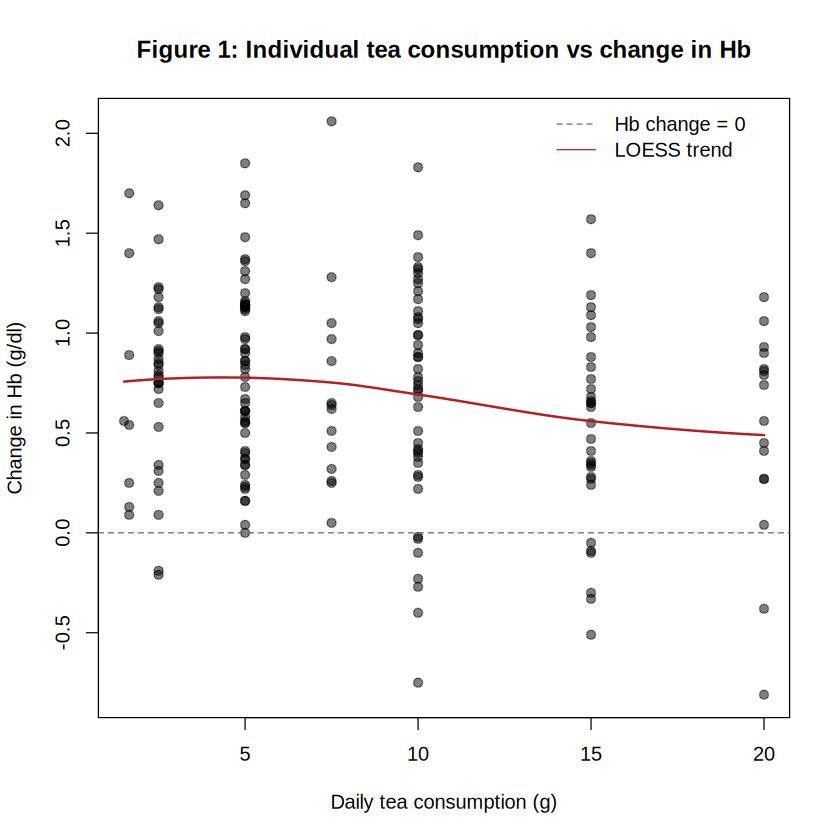

In [17]:
#individual tea_g vs change in Hb figure
plot(df$tea_g, df$hb_change, pch=19, col=rgb(0,0,0,0.5),
     xlab="Daily tea consumption (g)", ylab="Change in Hb (g/dl)",
     main="Figure 1: Individual tea consumption vs change in Hb")
abline(h=0, lty=2, col="grey40")
lo <- loess(hb_change ~ tea_g, data=df, span=1)
xs <- seq(min(df$tea_g), max(df$tea_g), length.out=100)
lines(xs, predict(lo, newdata=data.frame(tea_g=xs)), col="firebrick", lwd=2)
legend("topright", legend=c("Hb change = 0","LOESS trend"), col=c("grey40","firebrick"), lty=c(2,1), bty="n")

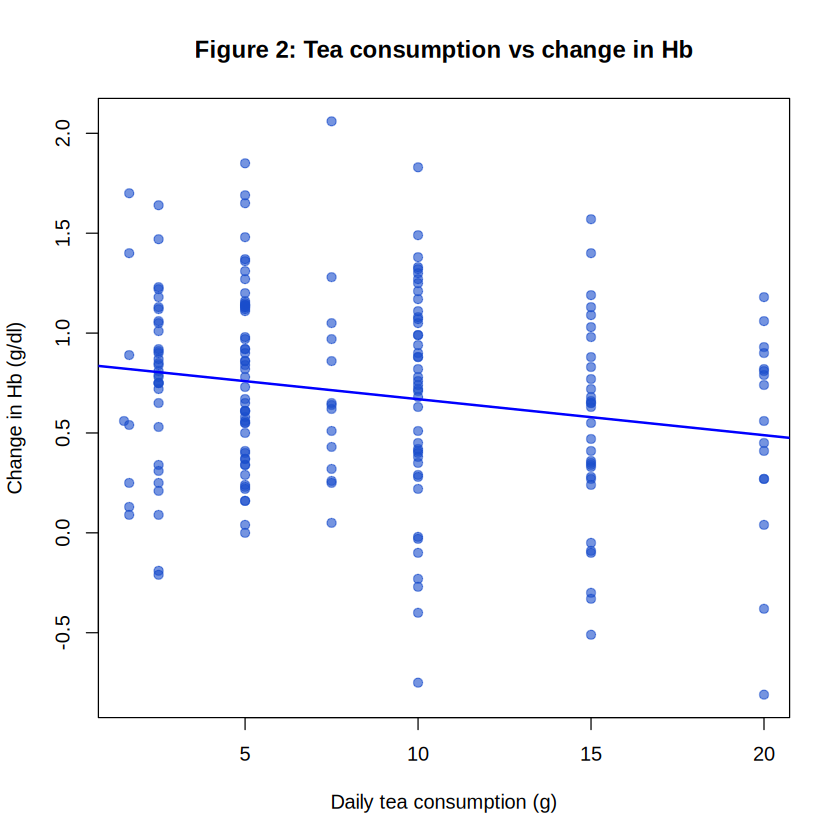

In [18]:
#tea consumption scatter plot and trend line figure
plot(df$tea_g, df$hb_change, pch=19, col=rgb(0.1,0.3,0.8,0.6),
     xlab="Daily tea consumption (g)", ylab="Change in Hb (g/dl)",
     main="Figure 2: Tea consumption vs change in Hb")
abline(lm(hb_change ~ tea_g, data=df), col="blue", lwd=2)

In [19]:
#sample coffee cohort
set.seed(42)
n_coffee <- 100
coffee_levels <- c(1.5, 2.5, 5, 7.5, 10, 15, 20)
coffee_g <- sample(coffee_levels, n_coffee, replace = TRUE, prob = c(3,6,6,3,3,2,1))
coffee_hb_change <- 0.55 - 0.045*coffee_g + rnorm(n_coffee, 0, 0.5)   # steeper slope than tea, on purpose, according to the literature
coffee <- data.frame(coffee_g, hb_change = round(coffee_hb_change, 2))

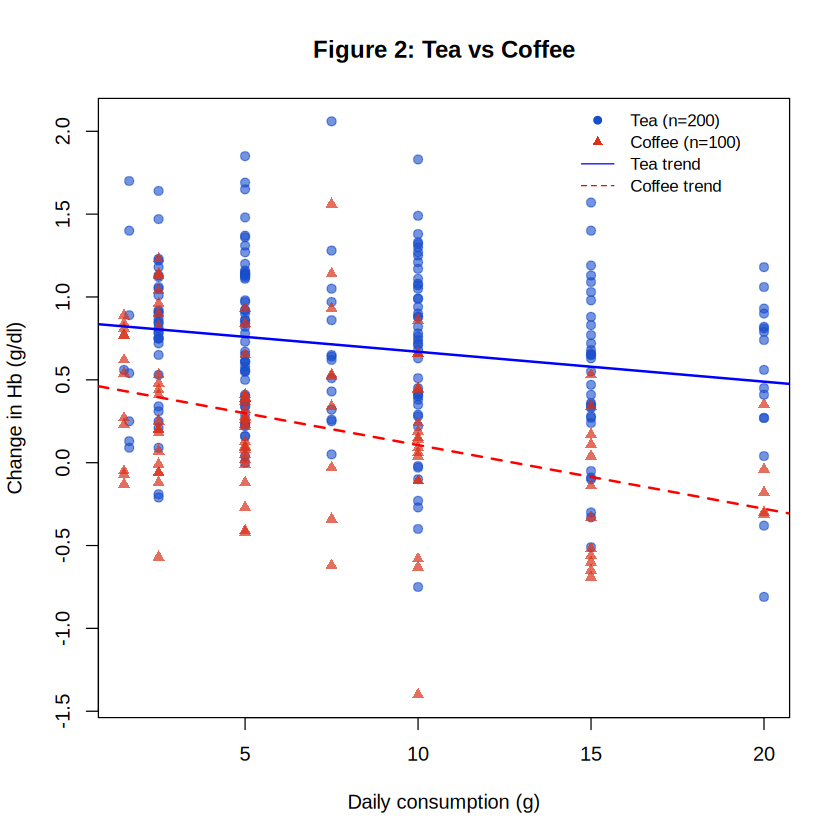

In [20]:
#combined tea and coffee scatter plot
plot(df$tea_g, df$hb_change, pch=19, col=rgb(0.1,0.3,0.8,0.6),
     xlim=range(c(df$tea_g, coffee$coffee_g)), ylim=range(c(df$hb_change, coffee$hb_change)),
     xlab="Daily consumption (g)", ylab="Change in Hb (g/dl)",
     main="Figure 2: Tea vs Coffee")
points(coffee$coffee_g, coffee$hb_change, pch=17, col=rgb(0.85,0.2,0.1,0.7))
abline(lm(hb_change ~ tea_g, data=df), col="blue", lwd=2)
abline(lm(hb_change ~ coffee_g, data=coffee), col="red", lwd=2, lty=2)
legend("topright", legend=c("Tea (n=200)","Coffee (n=100)","Tea trend","Coffee trend"),
       col=c(rgb(0.1,0.3,0.8),rgb(0.85,0.2,0.1),"blue","red"),
       pch=c(19,17,NA,NA), lty=c(NA,NA,1,2), bty="n", cex=0.85)

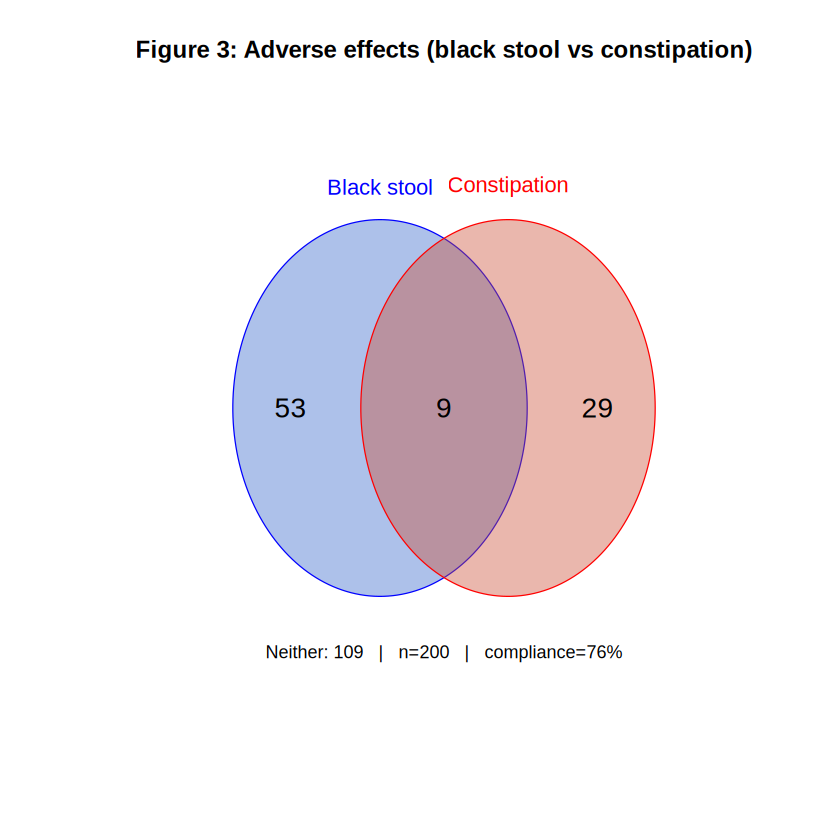

In [21]:
#adverse effects venn figure
bs_only <- sum(df$black_stool==1 & df$constipation==0)
co_only <- sum(df$black_stool==0 & df$constipation==1)
both    <- sum(df$black_stool==1 & df$constipation==1)
neither <- sum(df$black_stool==0 & df$constipation==0)

circle <- function(cx, cy, r, ...) {
  t <- seq(0, 2*pi, length.out=200)
  polygon(cx + r*cos(t), cy + r*sin(t), ...)
}

plot(NA, xlim=c(0,10), ylim=c(0,7), axes=FALSE, xlab="", ylab="",
     main="Figure 3: Adverse effects (black stool vs constipation)")
circle(4, 3.5, 2.3, col=rgb(0.2,0.4,0.8,0.4), border="blue")
circle(6, 3.5, 2.3, col=rgb(0.8,0.3,0.2,0.4), border="red")
text(2.6, 3.5, bs_only, cex=1.4); text(7.4, 3.5, co_only, cex=1.4); text(5, 3.5, both, cex=1.4)
text(4, 6.2, "Black stool", col="blue", cex=1.1)
text(6, 6.2, "Constipation", col="red", cex=1.1)
text(5, 0.5, paste0("Neither: ", neither, "   |   n=", nrow(df), "   |   compliance=",
                     round(100*mean(df$compliant),1),"%"), cex=0.9)